In [ ]:
import os
import torch
import pandas as pd
from pathlib import Path

# Path to the split dataset
data_dir = Path("/data/Minerva/20260129_split")

# Get all dataset names
datasets = sorted([d for d in os.listdir(data_dir) if os.path.isdir(data_dir / d)])
# remove "baselines" from the split dataset
if "baselines" in datasets:
    datasets.remove("baselines")


In [2]:
# Dictionary to store counts
counts = {}

# Iterate through each dataset
for dataset in datasets:
    dataset_path = data_dir / dataset
    counts[dataset] = {}
    
    # Count events in each split (train, val, test)
    for split in ['train', 'val', 'test']:
        split_path = dataset_path / split / "0.pb"
        
        if split_path.exists():
            # Load the data
            data = torch.load(split_path, weights_only=False)
            # Count the number of events (first dimension of truth_labels)
            n_events = data['truth_labels'].shape[0]
            counts[dataset][split] = n_events
        else:
            counts[dataset][split] = 0

# Create a DataFrame for nice table display
df = pd.DataFrame(counts).T
df = df[['train', 'val', 'test']]  # Ensure column order

# Add a total column
df['total'] = df.sum(axis=1)

# Add a row for totals
df.loc['Total'] = df.sum()

# Convert to millions
df_millions = df / 1_000_000

print("Number of events per dataset and split (in millions):")
print("=" * 60)
print(df_millions.round(2))
print("=" * 60)

Number of events per dataset and split (in millions):
           train   val  test  total
1A          6.08  0.76  0.76    7.6
baselines   0.00  0.00  0.00    0.0
Total       6.08  0.76  0.76    7.6


In [3]:

import torch._dynamo
# Iterate through each dataset
dataset_path = data_dir / "1A"

split_path = dataset_path / "train" / "0.pb"

# Load the data
data = torch.load(split_path, weights_only=True, mmap=True)

In [4]:
vals = data["data"].values()
offsets = data["data"].offsets()

In [5]:
vals.shape, offsets.shape, data.keys()

(torch.Size([92136418, 5]),
 torch.Size([6080807]),
 dict_keys(['data', 'truth_labels', 'global_features']))

In [6]:
event_id = 1000004
vals[offsets[event_id]:offsets[event_id+1]]

tensor([[ 0.6387, -0.4183,  4.7965,  4.9879,  1.0000],
        [-1.2513, -2.3587,  4.7215,  5.3584,  1.0000],
        [ 2.7302, -2.5013,  1.8011,  3.8424,  2.0000],
        [ 2.7882, -2.3099,  1.5806,  3.6794,  2.0000],
        [ 3.2044,  1.5489,  1.1615,  3.6744,  2.0000],
        [ 2.8900,  3.0717,  4.3314,  6.5313,  2.0000],
        [ 2.7227,  2.9121,  3.7935,  5.8273,  2.0000],
        [ 2.5152,  3.0346,  2.0826,  3.9112,  2.0000],
        [ 2.9298,  3.0817,  1.6023,  3.8419,  2.0000],
        [ 2.6049,  2.6710,  2.3100,  4.2272,  2.0000],
        [ 3.6531,  3.1416, -2.7541,  0.2065,  2.0000],
        [ 3.6257,  2.0944, -2.4092,  0.5241,  2.0000],
        [ 3.9052,  3.1416, -2.3684,  0.8441,  2.0000],
        [ 3.4676,  3.1416, -0.4723,  2.3032,  2.0000],
        [ 3.4248,  2.0944, -0.9346,  1.7982,  2.0000],
        [ 3.2112,  3.1416, -2.3436,  0.1760,  2.0000],
        [ 3.6761,  3.1416, -0.6467,  2.3369,  2.0000],
        [ 3.1453,  2.0944, -2.3120,  0.1419,  2.0000],
        [ 

In [7]:
import matplotlib.pyplot as plt
def plot_histogram_matrix(title, matrix, feature_names=None):
    # Matrix is of dim (N, n_features)
    # For each feature, make a histogram
    fig, axs = plt.subplots(matrix.shape[1], 2, figsize=(12.5, 20))
    for i in range(matrix.shape[1]):
        axs[i, 0].hist(matrix[:, i], bins=100)
        axs[i, 1].hist(matrix[:, i], bins=100)
        axs[i, 1].set_yscale('log')
        if feature_names is None:
            axs[i, 0].set_title(f"Feature {i}")
            axs[i, 0].set_title(f"Feature {i} (log)")
        else:
            axs[i, 0].set_title(feature_names[i])
            axs[i, 1].set_title(feature_names[i])
    fig.suptitle(title)
    return fig



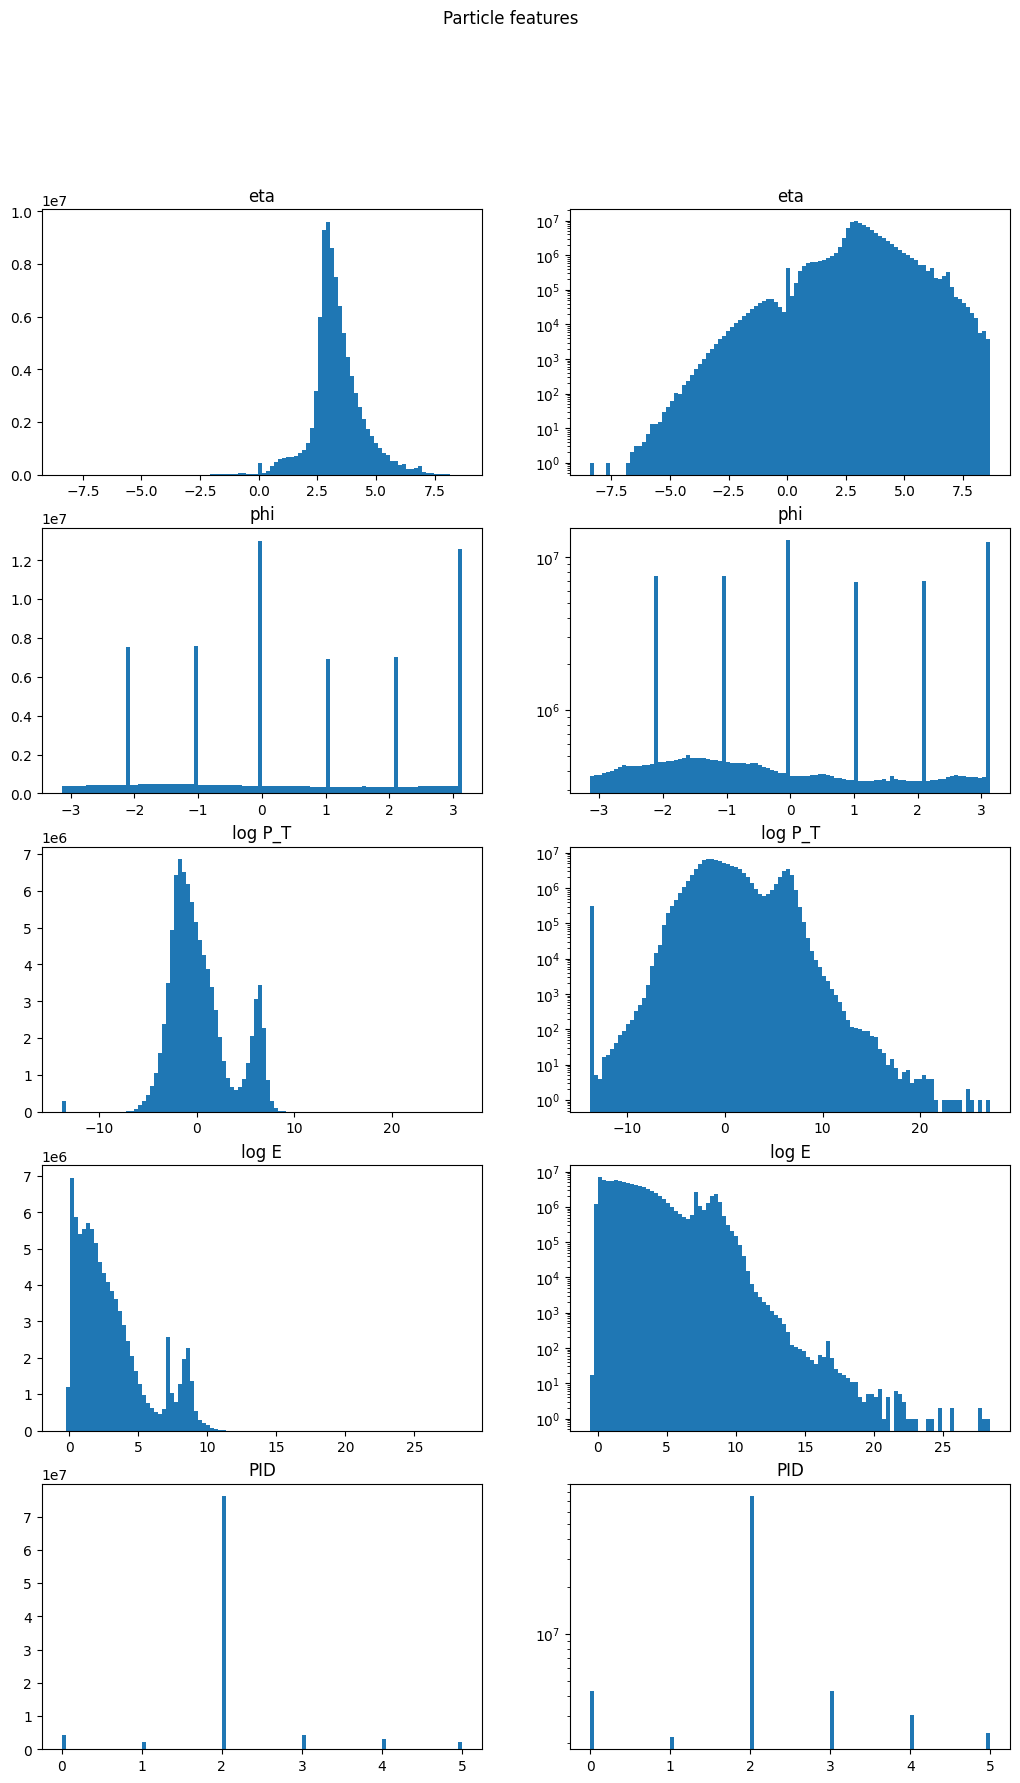

In [8]:
plot_histogram_matrix("Particle features", vals, ["eta", "phi", "log P_T", "log E", "PID"]).show()

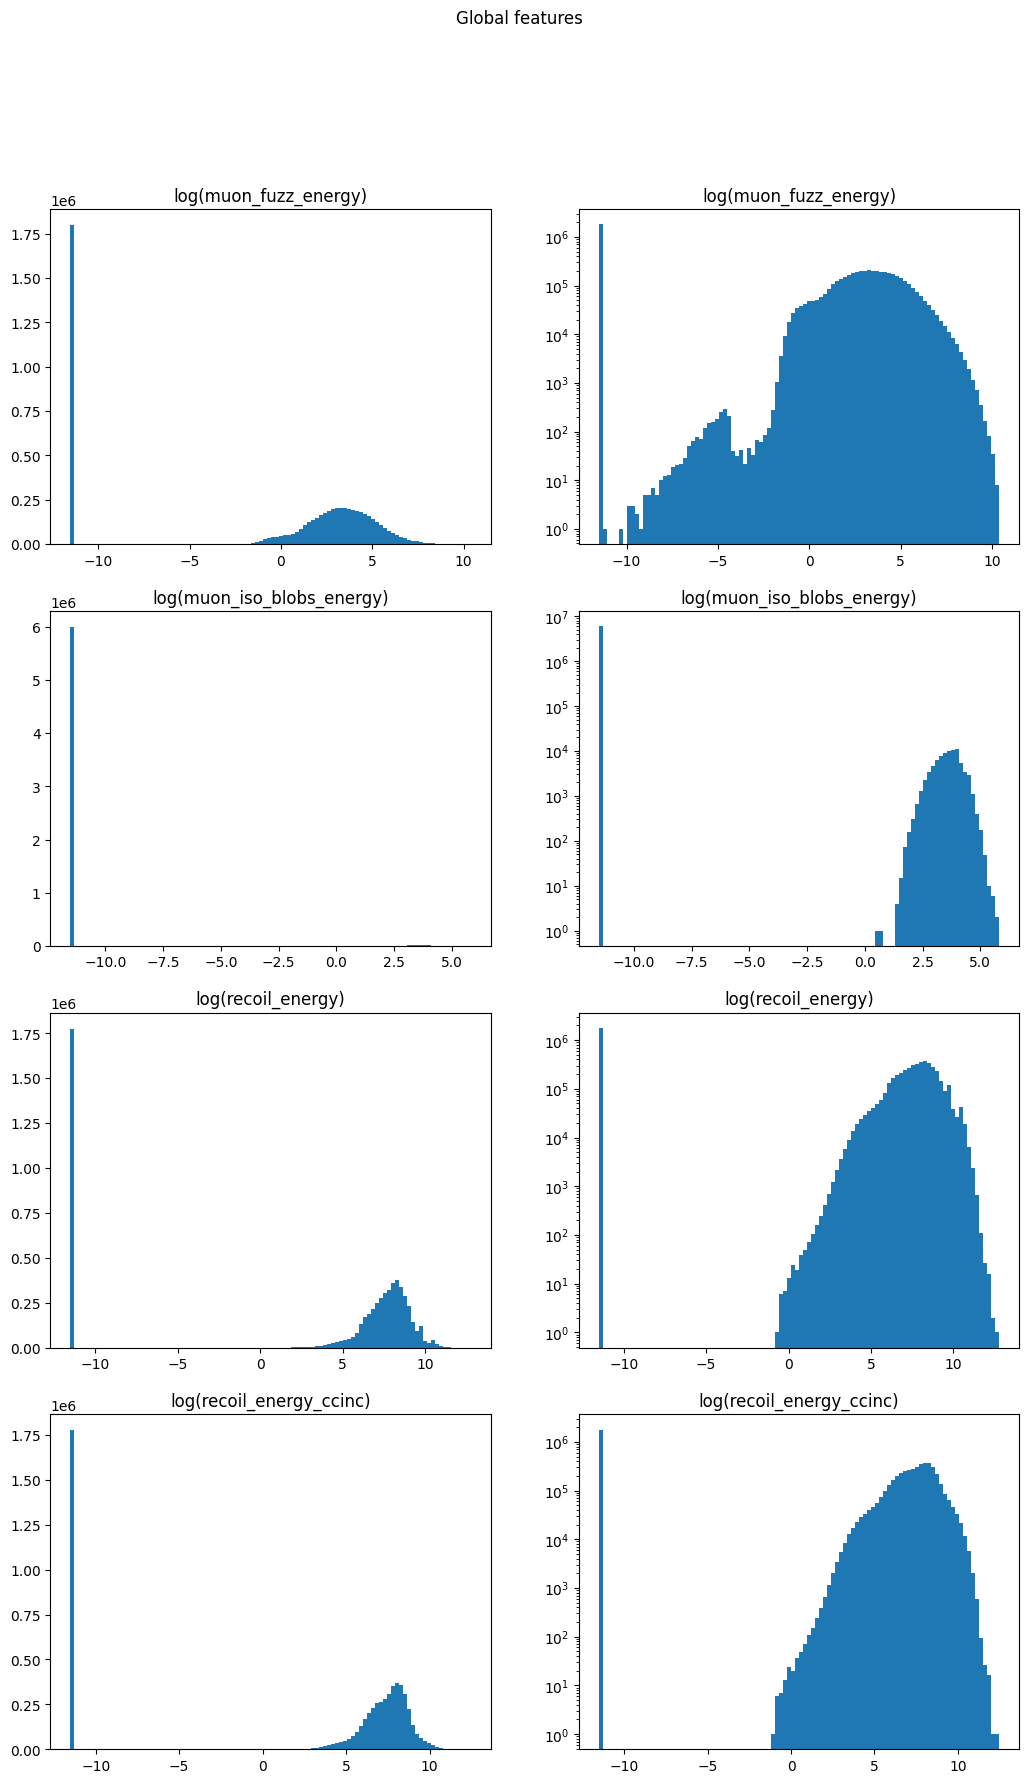

In [9]:
plot_histogram_matrix("Global features", data["global_features"], ["log(muon_fuzz_energy)", "log(muon_iso_blobs_energy)", "log(recoil_energy)", "log(recoil_energy_ccinc)"]).show()

In [10]:
data["truth_labels"][:, 2] /= data["truth_labels"][:, 0] 

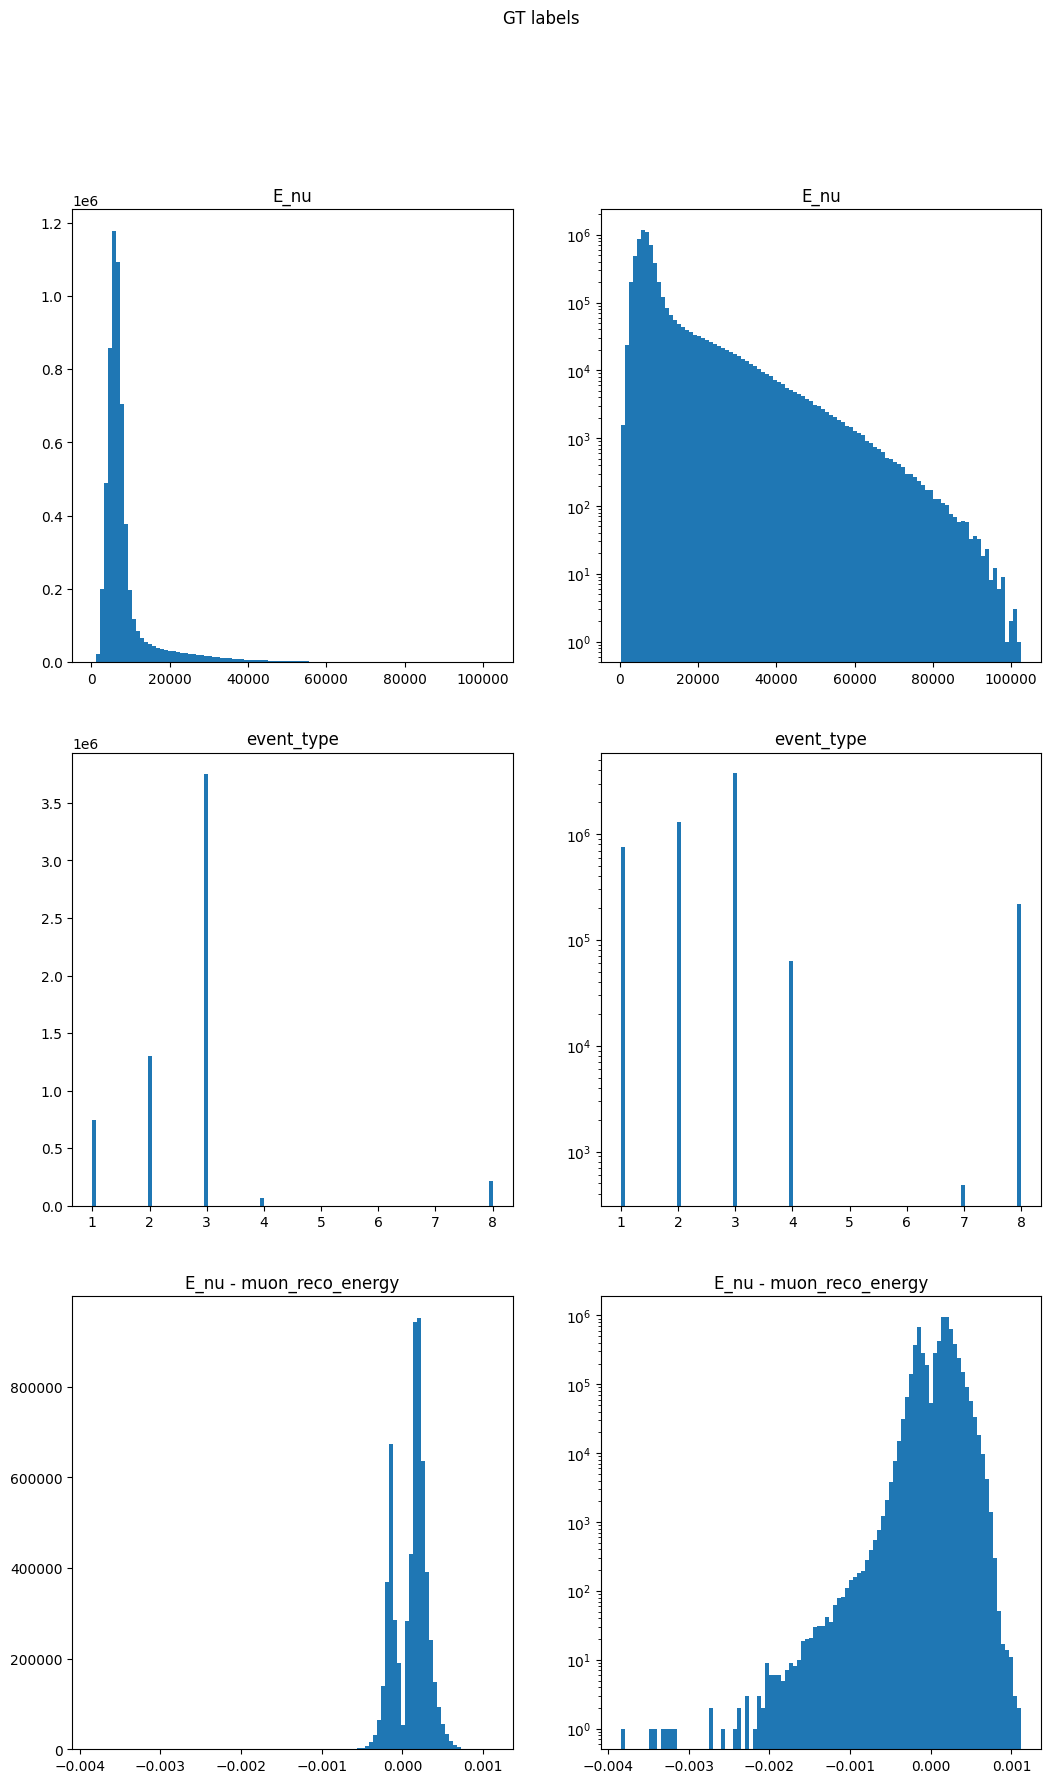

In [11]:
plot_histogram_matrix("GT labels", data["truth_labels"], ["E_nu", "event_type", "E_nu - muon_reco_energy"]).show()

In [17]:
import numpy as np
# check particles with logE <-10 and print their eta, phi, logP_T, logE, PID
particles = vals[np.where(vals[:, 3] < -10)]
print(particles.shape, particles, particles[:, -1])


torch.Size([0, 5]) tensor([], size=(0, 5), dtype=torch.float64) tensor([], dtype=torch.float64)


In [18]:
muon_reco_energy = -data["truth_labels"][:, 2] + data["truth_labels"][:, 0]

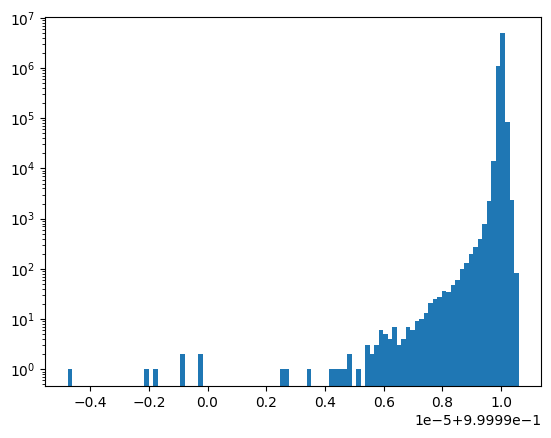

In [19]:
fig, ax=plt.subplots()
ax.hist(data["truth_labels"][:, 0] / muon_reco_energy, bins=100)
ax.set_yscale('log')


array([1., 2., 3., 4., 7., 8.])